# Exploratory Data Analysis for Time Series

Ten standard EDA plots applied to a single product from the French bakery daily-sales dataset.

Each section states **what the plot is**, **the code**, and **what it tells us about this series**. The order is deliberate: raw shape first, then distribution, then dependence structure, then decomposition.

**Series under study:** `TRADITIONAL BAGUETTE` -- the highest-volume product in the dataset (~145k units over 637 days), so the patterns are not drowned in noise.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pandas.plotting import lag_plot
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose

plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

## 0. Load and sanity-check

Before plotting anything, confirm the time index is **regular**: one row per period, no gaps, no duplicates. Almost every tool below (ACF, decomposition, rolling windows) silently assumes evenly spaced observations, and none of them will warn you if that assumption is broken.

`asfreq("D")` is the check: it reindexes onto a complete daily calendar and inserts `NaN` wherever a date was missing. Zero new `NaN`s means the coverage was already complete.

In [2]:
PRODUCT = "TRADITIONAL BAGUETTE"

df = pd.read_csv("../data/daily_sales_french_bakery.csv", parse_dates=["ds"])
s = df[df["unique_id"] == PRODUCT].sort_values("ds").set_index("ds")

y = s["y"].asfreq("D")   # regular daily index; NaN if a date was missing

print("product        :", PRODUCT)
print("rows           :", len(y))
print("date range     :", y.index.min().date(), "->", y.index.max().date())
print("gaps introduced:", int(y.isna().sum()))
print("duplicate dates:", int(s.index.duplicated().sum()))
print("zero-sale days :", int((y == 0).sum()))

y.describe().round(2)

product        : TRADITIONAL BAGUETTE
rows           : 637
date range     : 2021-01-02 -> 2022-09-30
gaps introduced: 0
duplicate dates: 0
zero-sale days : 37


count    637.00
mean     227.25
std      153.84
min        0.00
25%      128.40
50%      177.60
75%      301.20
max      919.10
Name: y, dtype: float64

**Read-out.** 637 daily observations from 2021-01-02 to 2022-09-30, no gaps and no duplicates -- unusually clean. But **37 days record zero sales**, and a zero is not the same thing as a missing value: it is a real observation that the shop sold nothing. Where do they fall?

In [3]:
zeros = y[y == 0]
print("zero days by weekday:")
print(zeros.groupby(zeros.index.day_name()).size().sort_values(ascending=False))

zero days by weekday:
ds
Wednesday    29
Monday        3
Thursday      2
Tuesday       2
Saturday      1
Name: y, dtype: int64


**29 of the 37 zeros land on a Wednesday** -- the shop is closed most Wednesdays. Keep this in mind: it will show up in *every* plot below, and in section 4 it produces a conclusion that is wrong twice over if taken at face value.

## 1. Line plot

The fundamental time series visualisation: time on the horizontal axis, the observed value on the vertical. Always the first plot you draw.

It reveals trend, seasonality, level shifts, outliers and gaps in one shot. Plot the **full history** to see slow structure, then **zoom in** -- fine-grained seasonality is invisible at 637 points on one axis.

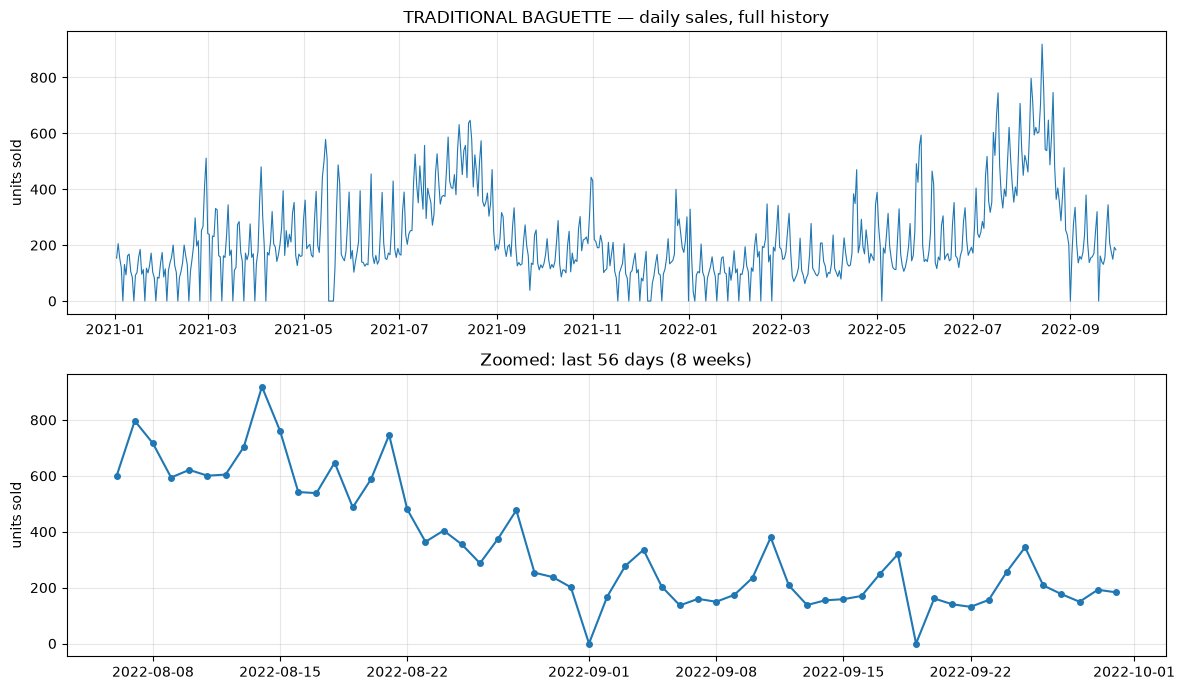

In [4]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7))

ax1.plot(y.index, y.values, lw=0.8)
ax1.set_title(f"{PRODUCT} — daily sales, full history")
ax1.set_ylabel("units sold")

recent = y.iloc[-56:]                      # last 8 weeks
ax2.plot(recent.index, recent.values, marker="o", ms=4)
ax2.set_title("Zoomed: last 56 days (8 weeks)")
ax2.set_ylabel("units sold")

plt.tight_layout()
plt.show()

**Observations**

- A massive **summer peak** in both 2021 and 2022 (July-August) against a January baseline near 105 units/day. It repeats, so it is signal, not an anomaly.
- **The baseline is flat but the amplitude is growing.** Comparing the overlapping Jan-Sep window, mean daily sales barely moved (236 in 2021 vs 242 in 2022, +2%), yet the peak went from 647 to 919 and August from 453 to 528. The annual swing is widening while the level holds -- a seasonal-amplitude change, not a trend.
- The zoomed panel is dominated by the **decline off the August peak**; the regular **7-day sawtooth** with hard drops to zero is clearest in the September stretch on the right.
- Variance is visibly larger when the level is high -- day-to-day swings in August dwarf those in January. That is *multiplicative* behaviour, and it matters for the choice of model (section 10).

## 2. Rolling mean and rolling standard deviation

A rolling window computes a statistic over a moving interval, smoothing away short-term noise:

$$\text{rolling mean}_t = \frac{1}{w}\sum_{i=t-w+1}^{t} y_i$$

- The **rolling mean** exposes the long-run level once the weekly cycle is averaged out. Use a window that is a multiple of the season length (here 28 or 30) so each window contains whole weeks.
- The **rolling standard deviation** answers a different question: is the spread stable over time?

Together they are the visual test for **stationarity** -- a stationary series has constant mean and constant variance.

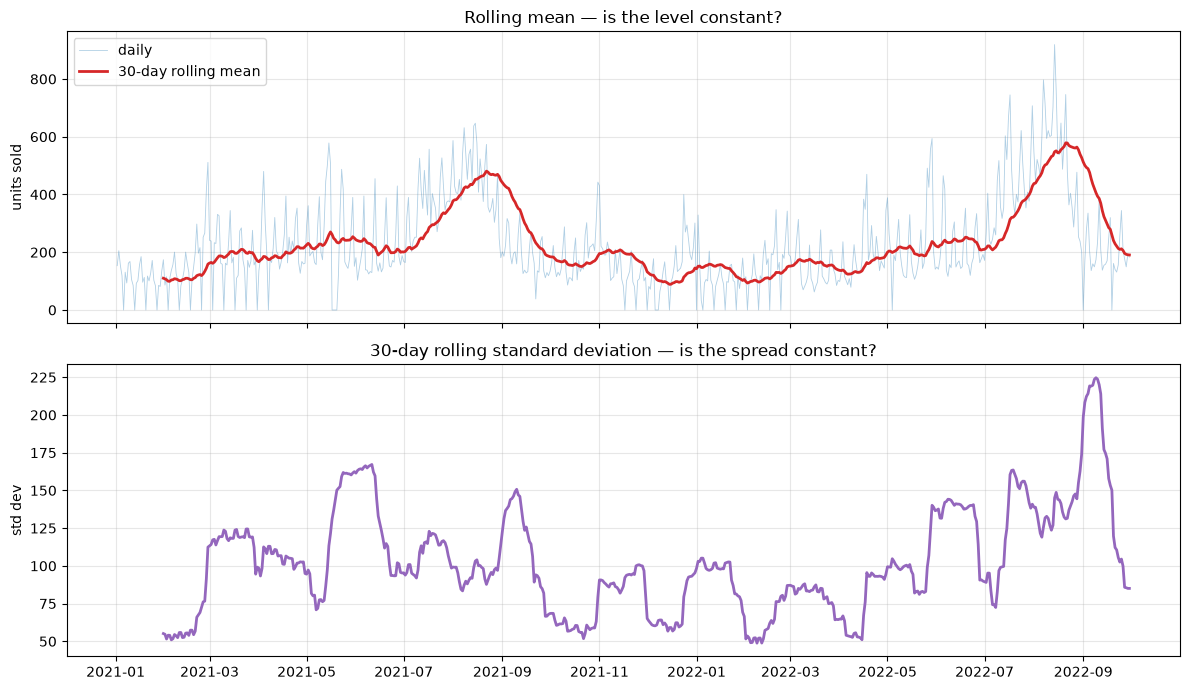

rolling mean ranges 89 -> 579
rolling std  ranges 49 -> 225


In [5]:
window = 30
roll_mean = y.rolling(window).mean()
roll_std  = y.rolling(window).std()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

ax1.plot(y.index, y.values, lw=0.6, alpha=0.35, label="daily")
ax1.plot(roll_mean.index, roll_mean.values, lw=2, color="tab:red",
         label=f"{window}-day rolling mean")
ax1.set_ylabel("units sold")
ax1.set_title("Rolling mean — is the level constant?")
ax1.legend()

ax2.plot(roll_std.index, roll_std.values, lw=2, color="tab:purple")
ax2.set_ylabel("std dev")
ax2.set_title(f"{window}-day rolling standard deviation — is the spread constant?")

plt.tight_layout()
plt.show()

print(f"rolling mean ranges {roll_mean.min():.0f} -> {roll_mean.max():.0f}")
print(f"rolling std  ranges {roll_std.min():.0f} -> {roll_std.max():.0f}")

**Observations**

- The rolling mean swings from **~89 to ~579** units/day. The mean is emphatically not constant, so the series is **non-stationary** in level.
- The rolling std moves from **~49 to ~225**, and it peaks exactly where the mean peaks. Variance scales with level -- **heteroscedasticity**.
- Both violations come from the *same* source (annual seasonality), not from a trend. The fix is therefore seasonal differencing or a seasonal model, not a first difference for trend.
- The variance issue argues for a **log or Box-Cox transform** before fitting anything that assumes constant error variance.

## 3. Seasonal plot

Rather than laying time out end to end, **overlay the cycles**. Each candidate season becomes one line, so you can see directly whether the pattern repeats or drifts.

This series has two nested seasons, so plot both: the weekly cycle (every week on the same weekday axis) and the annual cycle (each year as its own line across months).

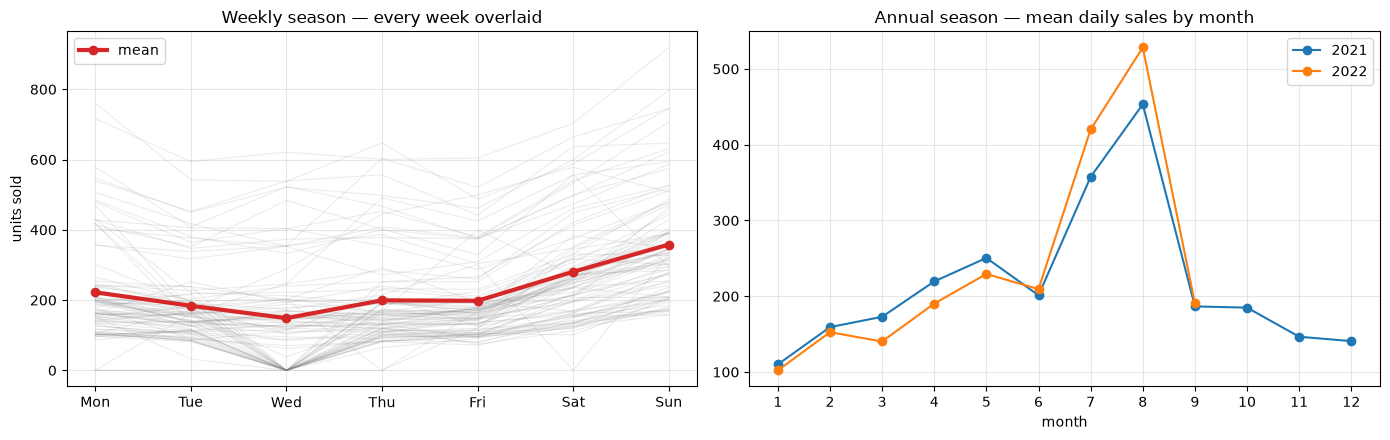

weekday
0    222.2
1    183.8
2    148.6
3    199.3
4    198.0
5    280.7
6    358.1


In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))

# --- weekly season: one faint line per week, mean profile on top
tmp = pd.DataFrame({"y": y})
tmp["weekday"] = tmp.index.dayofweek
tmp["week_id"] = tmp.index.to_period("W")

for _, grp in tmp.groupby("week_id"):
    ax1.plot(grp["weekday"], grp["y"], color="grey", alpha=0.15, lw=0.8)

profile = tmp.groupby("weekday")["y"].mean()
ax1.plot(profile.index, profile.values, color="tab:red", lw=3, marker="o", label="mean")
ax1.set_xticks(range(7))
ax1.set_xticklabels(["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])
ax1.set_ylabel("units sold")
ax1.set_title("Weekly season — every week overlaid")
ax1.legend()

# --- annual season: mean daily sales per month, one line per year
monthly = y.groupby([y.index.year, y.index.month]).mean().unstack(0)
for yr in monthly.columns:
    ax2.plot(monthly.index, monthly[yr], marker="o", label=str(yr))
ax2.set_xticks(range(1, 13))
ax2.set_xlabel("month")
ax2.set_title("Annual season — mean daily sales by month")
ax2.legend()

plt.tight_layout()
plt.show()

print(profile.round(1).to_string())

**Observations**

- The weekly profile is consistent across nearly every week: **Sunday is the peak (~358)**, Saturday second (~281), and Wednesday the trough (~149).
- The grey lines fan out vertically but keep the same *shape* -- the weekly pattern is **multiplicative** (it scales with the level) rather than additive.
- 2021 and 2022 trace the same annual arc, peaking in **August (~491)** against a **January trough (~106)**, a ~4.6x swing. Two years is thin evidence for an annual season, but the agreement between them is reassuring.
- 2022 stops at September -- the series ends mid-year, so the tail is not a decline.

## 4. Box plot by season

The seasonal plot shows every observation; a box plot **summarises the distribution** within each season -- median, interquartile range, and outliers -- making it easy to compare both the typical level and the variability.

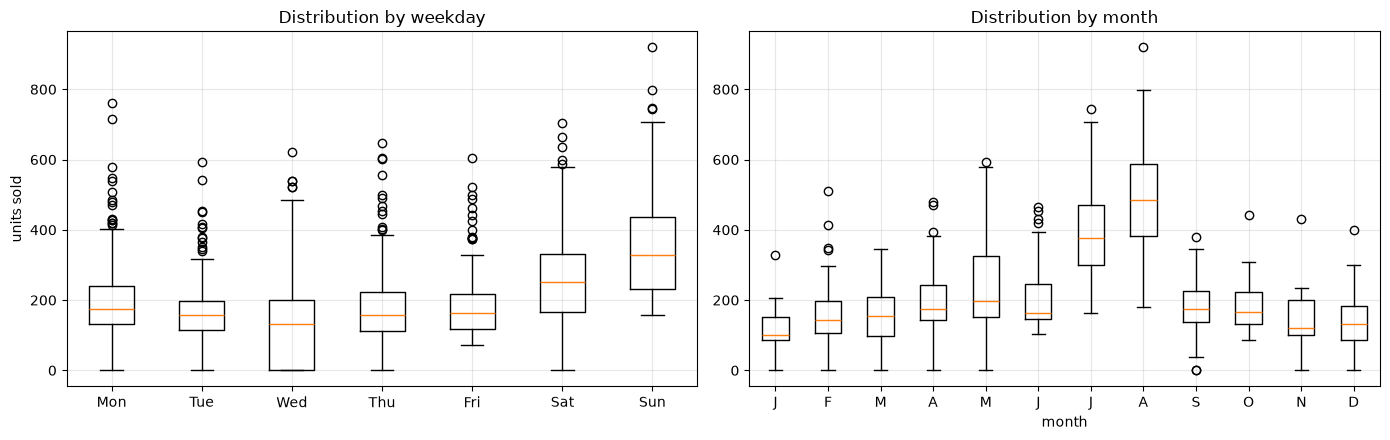

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))

by_weekday = [y[y.index.dayofweek == d].dropna().values for d in range(7)]
ax1.boxplot(by_weekday, tick_labels=["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])
ax1.set_ylabel("units sold")
ax1.set_title("Distribution by weekday")

by_month = [y[y.index.month == m].dropna().values for m in range(1, 13)]
ax2.boxplot(by_month, tick_labels=["J", "F", "M", "A", "M", "J", "J", "A", "S", "O", "N", "D"])
ax2.set_xlabel("month")
ax2.set_title("Distribution by month")

plt.tight_layout()
plt.show()

**Observations**

- Wednesday's box is stretched all the way down to zero -- those are the closure days, not weak trading.
- Spread grows with level: the July/August boxes are far taller than the winter ones. Same heteroscedasticity as section 2, now visible per season.
- Weekend boxes sit clearly above the weekday boxes with little overlap, confirming the weekly effect is real and not noise.

**The trap.** Taking the weekday medians at face value says "Wednesday is our worst day". Split out the closures and the story reverses:

In [ ]:
wed = y[y.index.dayofweek == 2]

print(f"Wednesday mean, all days     : {wed.mean():6.1f}")
print(f"Wednesday mean, open days    : {wed[wed > 0].mean():6.1f}")
print(f"Mon/Thu/Fri mean (comparison): {y[y.index.dayofweek.isin([0, 3, 4])].mean():6.1f}")

# ...but WHEN is the shop closed? If closures are seasonal, the comparison above is confounded.
print("\nclosed Wednesdays by month:", wed[wed == 0].groupby(wed[wed == 0].index.month).size().to_dict())
print("open   Wednesdays by month:", wed[wed > 0].groupby(wed[wed > 0].index.month).size().to_dict())

Two effects are stacked here, pulling in opposite directions.

**Closures drag the raw average down.** All Wednesdays average 148.6; open Wednesdays average 218.1, against 206.5 for Mon/Thu/Fri.

**But the open Wednesdays are not a fair sample.** The closures cluster in winter -- 21 of the 29 fall in January, February and March -- so the surviving open Wednesdays are concentrated in the high-demand summer months. Comparing them against a full-year average for other weekdays is not like-for-like, and it flatters Wednesday.

The fix is to compare within a period, or to measure each weekday against its own local level:

In [ ]:
# Like-for-like: each day as a ratio to its own local 7-day average, then averaged by weekday
local  = y.where(y > 0).rolling(7, center=True, min_periods=4).mean()
ratio  = y.where(y > 0) / local
factor = ratio.groupby(ratio.index.dayofweek).mean()

names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
print("multiplicative weekday factor (1.0 = the local weekly average), open days only")
for d, f in factor.items():
    print(f"  {names[d]}: {f:.2f}")

# and within-month, open Wednesdays vs all days
print("\nopen-Wednesday mean vs all-day mean, by month")
for m in [4, 5, 6, 7, 8]:
    w = wed[(wed > 0) & (wed.index.month == m)].mean()
    a = y[y.index.month == m].mean()
    print(f"  month {m:2d}: Wed {w:6.1f}   all days {a:6.1f}")

**Corrected conclusion.** Once the level is controlled for, **Wednesday really is the weakest trading day** -- a factor of **0.76** against the local weekly average, below Tuesday (0.79), Thursday (0.82), Friday (0.83) and Monday (0.94), with Saturday at 1.20 and Sunday at 1.55. The within-month comparison agrees: in every month from April to August, open Wednesdays run *below* that month's all-day average.

So the naive average misleads in **both** directions:

- Including closures says Wednesday sells 148.6 -- far too pessimistic.
- Excluding them says 218.1, in line with Mon/Thu/Fri -- too optimistic, because the surviving Wednesdays are disproportionately summer days.

The real lesson is broader than "separate structural zeros from demand", though that still stands: **when you filter rows, check what else you filtered.** Removing the closures also silently removed most of winter, and any weekday comparison built on the filtered sample inherits that bias. Compare like-for-like -- within a period, or against a local baseline.

For modelling, the practical consequence is unchanged: closures need a **flag of their own** so the model learns the opening calendar separately from demand.

## 5. Histogram

A histogram shows the **marginal distribution** of the values, discarding temporal order entirely. It answers: is the distribution symmetric or skewed, unimodal or multimodal, and are there extreme values?

Losing the time ordering is a real cost, but the shape drives concrete decisions -- whether to transform, and whether a Gaussian error assumption is defensible.

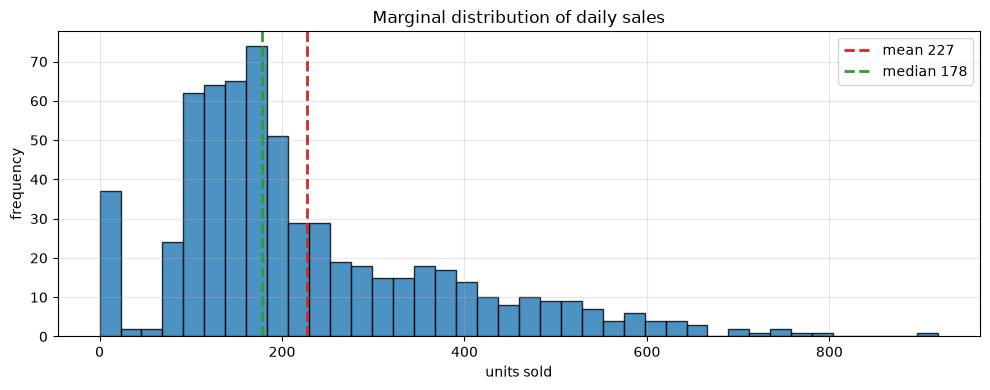

skewness : 1.20
kurtosis : 1.42
mean 227.2 vs median 177.6


In [9]:
fig, ax = plt.subplots(figsize=(10, 4))

ax.hist(y.dropna().values, bins=40, edgecolor="black", alpha=0.8)
ax.axvline(y.mean(),   color="tab:red",   ls="--", lw=2, label=f"mean {y.mean():.0f}")
ax.axvline(y.median(), color="tab:green", ls="--", lw=2, label=f"median {y.median():.0f}")
ax.set_xlabel("units sold")
ax.set_ylabel("frequency")
ax.set_title("Marginal distribution of daily sales")
ax.legend()

plt.tight_layout()
plt.show()

print(f"skewness : {y.skew():.2f}")
print(f"kurtosis : {y.kurt():.2f}")
print(f"mean {y.mean():.1f} vs median {y.median():.1f}")

**Observations**

- **Right-skewed** (skew = 1.20): mean 227 sits well above median 178, dragged up by the summer tail out to 919 units.
- A **spike at zero**, separate from the main body -- the closure days again. Strictly this makes the distribution bimodal, but the second mode is a different data-generating process, not a second demand regime.
- Sales are **non-negative counts**, and the skew plus the hard floor at zero mean a symmetric Gaussian is a poor description. Prediction intervals built on normality will extend below zero.

## 6. Density plot (kernel density estimate)

A KDE is a smoothed histogram: it places a small kernel on each observation and sums them, removing the arbitrariness of bin edges. Useful for comparing distributions -- for example, before and after a transform.

Since section 2 flagged variance that scales with level, the natural question is whether a log transform stabilises it.

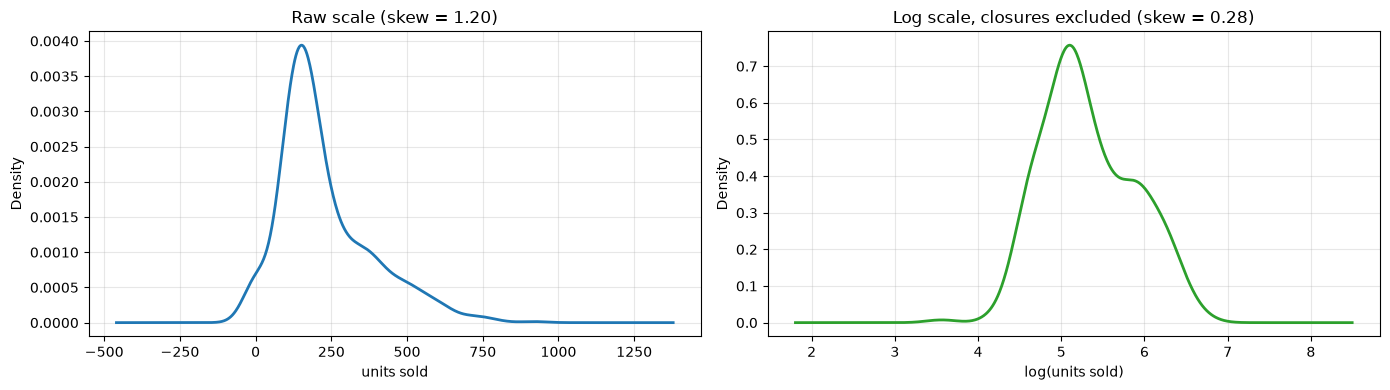

raw skew                    : 1.20
log1p skew, zeros kept      : -2.80
log skew, zeros excluded    : 0.28


In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

y.plot(kind="density", ax=ax1, lw=2)
ax1.set_xlabel("units sold")
ax1.set_title(f"Raw scale (skew = {y.skew():.2f})")

positive = y[y > 0]
np.log(positive).plot(kind="density", ax=ax2, lw=2, color="tab:green")
ax2.set_xlabel("log(units sold)")
ax2.set_title(f"Log scale, closures excluded (skew = {np.log(positive).skew():.2f})")

plt.tight_layout()
plt.show()

print(f"raw skew                    : {y.skew():.2f}")
print(f"log1p skew, zeros kept      : {np.log1p(y).skew():.2f}")
print(f"log skew, zeros excluded    : {np.log(positive).skew():.2f}")

**Observations**

- The raw KDE spreads its mass over a long right tail, with a bump at zero.
- Taking logs of the **open days** pulls skew from **1.20 down to 0.28** -- near symmetric. A log transform is the right pre-processing step for this series.
- But `log1p` with the zeros left in swings skew to **-2.80**: the zeros map to 0 while everything else lands near 5-6, manufacturing a heavy *left* tail. **Handle the closures first, transform second** -- the naive `log1p` is worse than no transform at all.
- Note the KDE smooths across the hard boundary at zero and puts density on impossible negative values. It is a visual aid, not a model of the data.

## 7. Lag plot

Plot each observation against an earlier one: $y_t$ on the vertical axis, $y_{t-k}$ on the horizontal. This is the most intuitive picture of **autocorrelation**.

- Points along a rising diagonal -> strong positive dependence at that lag.
- A shapeless cloud -> no dependence at that lag; the past carries no information about the present.

Choose lags that mean something: lag 1 (yesterday) and lag 7 (same weekday last week).

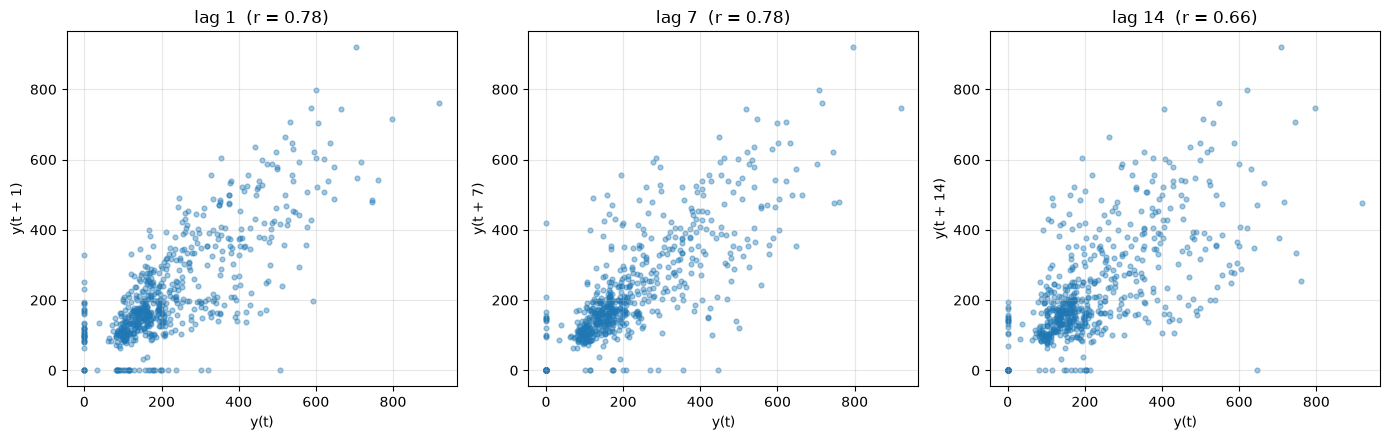

autocorrelation at lag  1: 0.777
autocorrelation at lag  7: 0.783
autocorrelation at lag 14: 0.656
autocorrelation at lag 21: 0.548
autocorrelation at lag 30: 0.185


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

for ax, lag in zip(axes, [1, 7, 14]):
    lag_plot(y, lag=lag, ax=ax, alpha=0.4, s=12)
    ax.set_title(f"lag {lag}  (r = {y.autocorr(lag):.2f})")

plt.tight_layout()
plt.show()

for lag in [1, 7, 14, 21, 30]:
    print(f"autocorrelation at lag {lag:2d}: {y.autocorr(lag):.3f}")

**Observations**

- All three panels show a clear rising diagonal -- this series is strongly autocorrelated, so the past is genuinely predictive.
- **Lag 7 (r = 0.783) is fractionally stronger than lag 1 (r = 0.777)**, and both dominate lag 14 (0.656). Last week's same weekday is as informative as yesterday -- the signature of weekly seasonality.
- The cloud widens as values grow -- a scatter-plot view of the same heteroscedasticity.
- Points stuck on the axes are closure days pairing a zero with a normal value.

## 8. Autocorrelation function (ACF)

The lag plot handles one lag at a time; the ACF plots **all** of them at once. The autocorrelation at lag $k$ is

$$r_k = \frac{\sum_{t=k+1}^{T}(y_t - \bar{y})(y_{t-k} - \bar{y})}{\sum_{t=1}^{T}(y_t - \bar{y})^2}$$

The shaded band is the 95% confidence region for "no correlation" -- spikes outside it are statistically significant. How to read it:

- **Slow linear decay** -> trend or non-stationarity.
- **Spikes at multiples of $m$** -> seasonality of period $m$.
- **Sharp cut-off after lag $q$** -> an MA($q$) component.

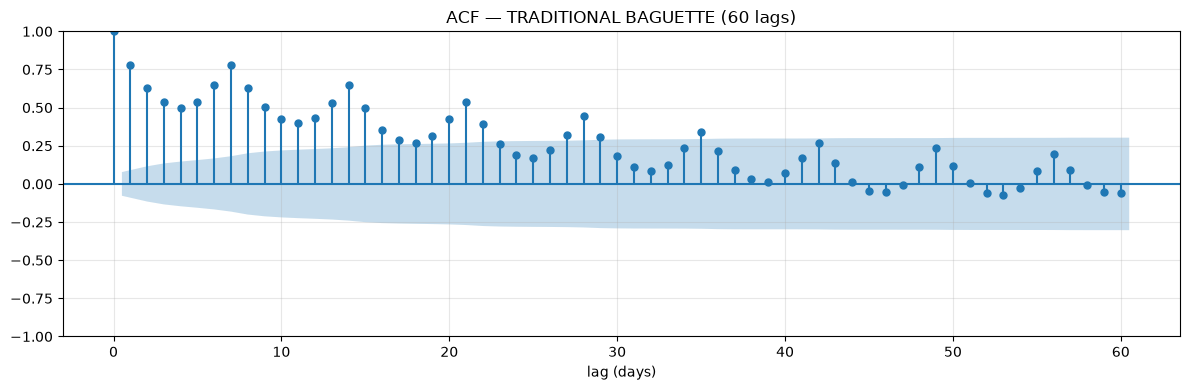

In [12]:
fig, ax = plt.subplots(figsize=(12, 4))
plot_acf(y.dropna(), lags=60, ax=ax)
ax.set_title(f"ACF — {PRODUCT} (60 lags)")
ax.set_xlabel("lag (days)")
plt.tight_layout()
plt.show()

**Observations**

- Autocorrelations stay significant far out and **decay slowly** -- the standard fingerprint of a non-stationary series, matching the rolling-mean plot.
- Local **peaks at lags 7, 14, 21, 28** confirm the weekly season; this is the empirical justification for `season_length=7`.
- Because the decay never really dies out within 60 lags, differencing (a first difference, a seasonal difference at lag 7, or both) is needed before fitting an ARMA model.

## 9. Partial autocorrelation function (PACF)

The ACF at lag 7 is inflated by everything in between: if today depends on yesterday and yesterday on the day before, a lag-7 correlation appears even with no direct link.

The PACF strips that out -- it measures the correlation between $y_t$ and $y_{t-k}$ **after regressing out lags $1 \dots k-1$**, isolating the direct effect. This is what identifies the AR order:

- **ACF tails off, PACF cuts off after lag $p$** -> AR($p$).
- **ACF cuts off after lag $q$, PACF tails off** -> MA($q$).

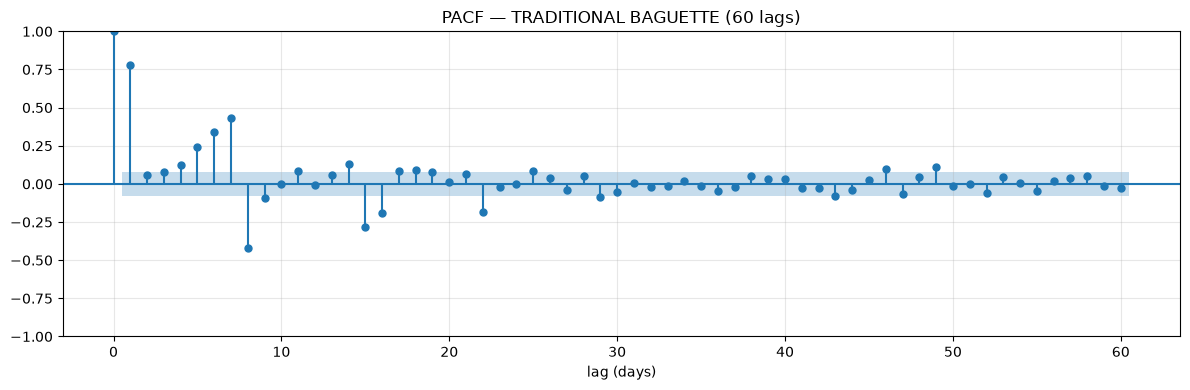

In [13]:
fig, ax = plt.subplots(figsize=(12, 4))
plot_pacf(y.dropna(), lags=60, ax=ax, method="ywm")
ax.set_title(f"PACF — {PRODUCT} (60 lags)")
ax.set_xlabel("lag (days)")
plt.tight_layout()
plt.show()

**Observations**

- A dominant spike at **lag 1 (~0.78)**, then an immediate collapse -- most of the day-to-day persistence is direct, and the ACF's slow decay is inherited through the chain rather than real dependence at every lag.
- Spikes build back up into **lag 7 (~0.43)** and are followed by a strong **negative spike at lag 8 (~-0.42)**, with the alternating pattern echoing weakly at lags 15 and 22. That positive/negative pair around the seasonal lag is direct evidence of a genuine seasonal AR term, not an echo of lag 1.
- Beyond ~lag 25 essentially everything sits inside the confidence band -- no long-memory structure to model.
- The pattern (ACF tailing off slowly, PACF cutting off early with a lag-7 feature) points at a low-order AR with a seasonal component -- roughly `SARIMA(1,d,0)(1,D,0)[7]` as a starting guess. `AutoARIMA` will search the neighbourhood, but the plots tell you whether its answer is sane.

## 10. Seasonal decomposition

Split the series into three interpretable pieces:

$$\text{additive:}\quad y_t = T_t + S_t + R_t \qquad\qquad \text{multiplicative:}\quad y_t = T_t \times S_t \times R_t$$

with $T_t$ the trend-cycle (a centred moving average), $S_t$ the repeating seasonal component, and $R_t$ the remainder.

**Which model?** If the seasonal swing grows with the level -- as sections 1 and 3 showed -- the relationship is multiplicative. Fit additive on the log scale and you get the same thing, since $\log(T \times S \times R) = \log T + \log S + \log R$.

`period=7` extracts the weekly season. The annual season cannot be extracted here: `seasonal_decompose` needs two full periods and 637 days is only 1.7 years.

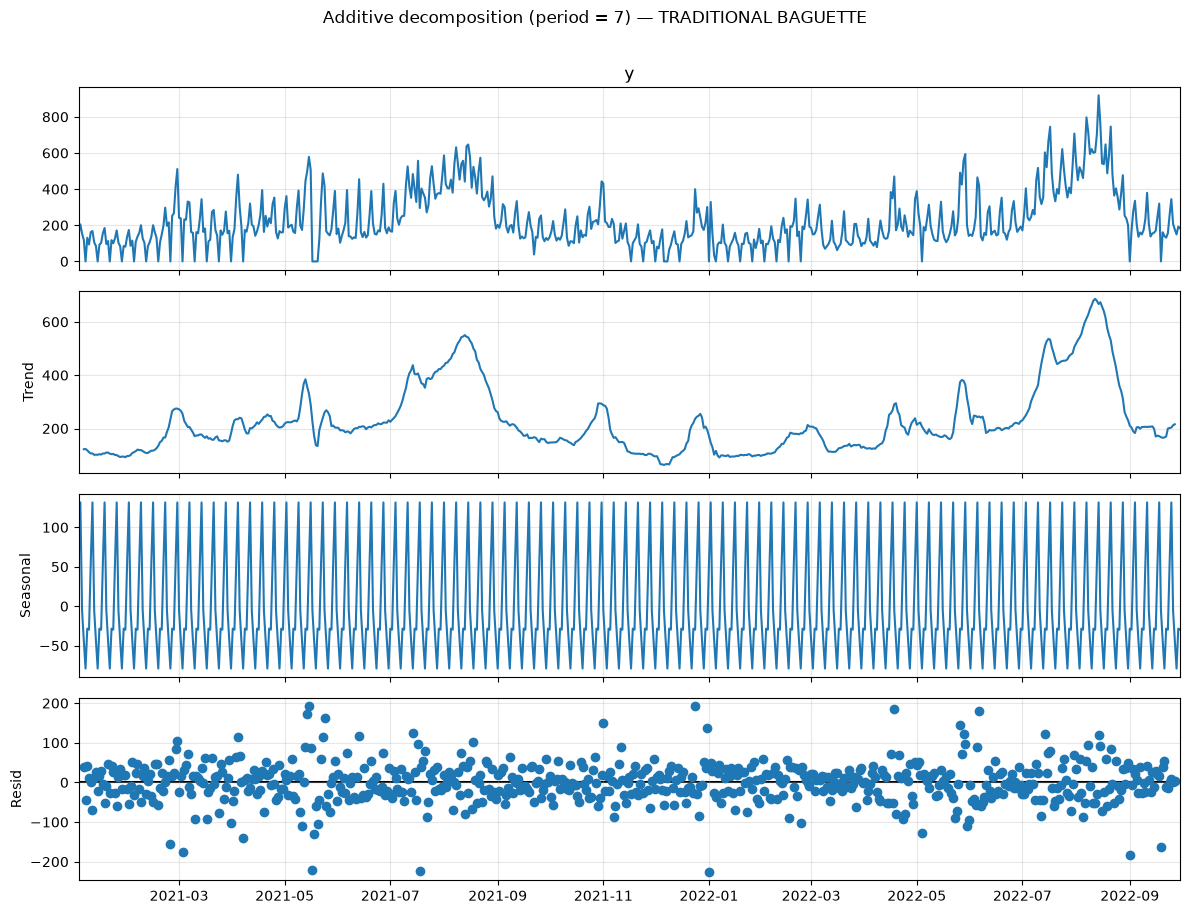

In [14]:
result = seasonal_decompose(y.dropna(), model="additive", period=7)

fig = result.plot()
fig.set_size_inches(12, 9)
fig.suptitle(f"Additive decomposition (period = 7) — {PRODUCT}", y=1.01)
plt.tight_layout()
plt.show()

In [15]:
# Strength of trend and seasonality (Hyndman): 1 - Var(remainder) / Var(remainder + component)
parts = pd.concat(
    {"resid": result.resid, "seasonal": result.seasonal, "trend": result.trend},
    axis=1,
).dropna()

F_seasonal = max(0, 1 - parts["resid"].var() / (parts["resid"] + parts["seasonal"]).var())
F_trend    = max(0, 1 - parts["resid"].var() / (parts["resid"] + parts["trend"]).var())

print(f"strength of seasonality : {F_seasonal:.3f}")
print(f"strength of trend-cycle : {F_trend:.3f}")
print(f"seasonal component range: {result.seasonal.min():.0f} to {result.seasonal.max():.0f} units")

strength of seasonality : 0.629
strength of trend-cycle : 0.870
seasonal component range: -79 to 132 units


**Observations**

- **Trend-cycle:** the summer humps dominate, with narrow isolated spikes elsewhere (holidays and one-off busy days). With `period=7` the annual season has nowhere else to go, so it is absorbed here -- this component is *not* a long-run growth trend, and reading it as one would be a mistake.
- **Seasonal:** a fixed weekly pattern spanning **-79 to +132 units**, drawn at identical amplitude in January and August. That is the additive-vs-multiplicative mismatch made visible: it overstates the winter swing and understates the summer one. `STL` (with `robust=True`) lets the seasonal shape evolve and handles the closure outliers better.
- **Remainder:** mostly within +/-100 but with the widest scatter around the summer peaks, and large negative outliers reaching -200 -- those are the closure days, where a zero lands on a day the fixed weekly pattern expected to be busy. No constant seasonal component can reproduce them.
- **Strength scores:** seasonality **0.63** and trend-cycle **0.87** on a 0-1 scale. Both components are strong, so a model with only one of them will leave real structure on the table.

## Summary — what the EDA established

| Question | Finding | Consequence |
|---|---|---|
| Regular index? | 637 days, no gaps or duplicates | no resampling needed |
| Missing vs zero? | 37 zeros, 29 on Wednesdays (closures), clustered in winter | flag them; do not model as demand, and beware the bias they leave behind |
| Stationary in mean? | No -- rolling mean 89 to 579 | seasonal differencing / seasonal model |
| Stationary in variance? | No -- rolling std 49 to 225, scaling with level | log or Box-Cox transform |
| Seasonality? | Weekly ($F_s = 0.63$) plus annual (Aug ~4.6x Jan) | `season_length=7`; annual needs Fourier terms |
| Trend? | None year on year; the "trend" is the annual cycle | do not difference for trend |
| Autocorrelation? | $r_1 = 0.78$, $r_7 = 0.78$ | the past is genuinely predictive |
| Model order? | ACF tails off, PACF cuts off at 1 with a lag-7 spike | start near `SARIMA(1,d,0)(1,D,0)[7]` |
| Distribution? | Right-skewed (1.20), zero-inflated, non-negative counts | Gaussian intervals will go negative |

**The one finding that would have been missed without EDA:** Wednesday's mean of 149 is not weak demand -- it is 29 closure days. But excluding them gives 218, which is also misleading, because the closures cluster in winter and the surviving Wednesdays are mostly summer days. Measured against the local weekly level, Wednesday is genuinely the weakest day at a factor of 0.76. Filtering rows changed the seasonal composition of the sample -- always check what else a filter removed.

**Next steps:** mask closure days -> log transform -> `SARIMA(...)[7]` with Fourier terms for the annual cycle, validated with rolling-origin cross-validation.